In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle 
from scipy.interpolate import interp1d
from grabmustang import geoStation

In [2]:
start_date = pd.to_datetime('2008-01-01',format='%Y-%m-%d')
end_date = pd.to_datetime('2024-06-01',format='%Y-%m-%d')


In [ ]:
from datetime import datetime, timedelta
from time import sleep

# Get seismic spectra

# Ely, Minnesota, USA
comp = ['BHZ']
US_EYMN = geoStation('US', 'EYMN', ['**'], comp, label='Ely, Minnesota, USA')
station_list = [US_EYMN]

# # Erie, Pennsylvania, USA
# comp = ['BHZ']
# US_ERPA = geoStation('US', 'ERPA', ['**'], comp, label='Erie, Pennsylvania, USA')
# station_list = [US_ERPA]

# # Sadowa, ON, CA
# comp = ['BHZ']
# CN_SADO = geoStation('CN', 'SADO', ['**'], comp, label='Sadowa, ON, CA')
# station_list = [CN_SADO]

dof = 0
# plotunit = 2 # 2=acceleration, 1=velocity, 0=displacement
plotunit = 2 # 2=acceleration, 1=velocity, 0=displacement

# Vector of datetimes spaced every 24 hours
# datevec = np.arange(df['date'].dt.round('1d').min(),df['date'].dt.round('1d').max(), timedelta(days=1))
# datevec = df['date'].to_numpy()
# datevec_end = np.append(df['date'][1:].to_numpy(),(df['date'][-1]+(df['date'][-1]-df['date'][-2])).to_numpy())
dt_days = 8
datevec = np.arange(start_date,end_date, timedelta(days=dt_days))

pd.options.mode.chained_assignment = None  # default='warn' suppress annoying warning
for station in station_list:
    # Get average noise properties
    PSD_avg = 0
    PSDs = []
    icnt = 0
    freqs = np.array([])
    for iday in range(len(datevec)):
        tstart = datevec[iday] - np.timedelta64(int(dt_days/2),'D') #- timedelta(1) # -24 hours
        tend = datevec[iday] + np.timedelta64(int(dt_days/2),'D') # +24 hours
        # tend = datevec_end[iday]

        tstart_str = tstart.astype('datetime64[s]').item().strftime('%Y-%m-%d')
        tend_str = tend.astype('datetime64[s]').item().strftime('%Y-%m-%d')

        print('Working on '+tstart_str+' to '+tend_str)

        try:
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        except:
            print('IRIS unhappy... trying again')
            sleep(2)
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        
        if len(station.text_percentiles[dof]) < 50:
            print('Missing '+tstart_str+' trying HHZ component')
            sleep(2)
            station.channels = [c.replace('B','H') for c in station.channels]
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)

            # Switch back to BHZ
            station.channels = comp

            if len(station.text_percentiles[dof]) < 50:
                print('skipping '+tstart_str)

                PSDs.append(np.nan*np.ones(freqs.shape))
                continue
            
            # # Interpolate to same frequency axis
            # station.text_percentiles[dof] = interp1d(station.freqs[dof],station.text_percentiles[dof])(freqs)

        else:
            if freqs.size == 0:
                # print('saving freqs')
                freqs = station.freqs[dof]

        if station.freqs[dof].size != freqs.size:
            # Interpolate to same frequency axis
            station.text_percentiles[dof] = interp1d(station.freqs[dof],station.text_percentiles[dof])(freqs)
        
        PSD = 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*freqs)**(2-plotunit))

        PSDs.append(PSD)
        
        PSD_avg = PSD_avg + PSD
        icnt+=1

    PSD_avg = PSD_avg / icnt
    PSDs = np.asarray(PSDs)

    # Save pkl file of PSD spectrogram
    fs,ts = np.meshgrid(freqs,datevec)

    # Create a variable 
    data_PSDs = {'PSD': PSDs, 'ts': ts, 'fs': fs, 'freqs': freqs, 'datevec': datevec,
                 'station': station.station, 'network':station.network, 'comp':station.channels[dof],
                 'label': station.label}

    filename = './PSDs/PSD_'+station.network+'_'+station.station+'_'+station.channels[dof]+'_'+start_date.strftime('%Y%m%d')+'_'+end_date.strftime('%Y%m%d')+'_dt'+str(int(dt_days))+'days.pkl'

    # Open a file and use dump() 
    with open(filename, 'wb') as file: 
        # A new file will be created 
        pickle.dump(data_PSDs, file)


Working on 2007-12-28 to 2008-01-05
Working on 2008-01-05 to 2008-01-13
Working on 2008-01-13 to 2008-01-21
Working on 2008-01-21 to 2008-01-29
Working on 2008-01-29 to 2008-02-06
Working on 2008-02-06 to 2008-02-14
Working on 2008-02-14 to 2008-02-22
Working on 2008-02-22 to 2008-03-01
Working on 2008-03-01 to 2008-03-09
Working on 2008-03-09 to 2008-03-17
Working on 2008-03-17 to 2008-03-25
Working on 2008-03-25 to 2008-04-02
Working on 2008-04-02 to 2008-04-10
Working on 2008-04-10 to 2008-04-18
Working on 2008-04-18 to 2008-04-26
Working on 2008-04-26 to 2008-05-04
Working on 2008-05-04 to 2008-05-12
Working on 2008-05-12 to 2008-05-20
Working on 2008-05-20 to 2008-05-28
Working on 2008-05-28 to 2008-06-05
Working on 2008-06-05 to 2008-06-13
Working on 2008-06-13 to 2008-06-21
Working on 2008-06-21 to 2008-06-29
Working on 2008-06-29 to 2008-07-07
Working on 2008-07-07 to 2008-07-15
Working on 2008-07-15 to 2008-07-23
Working on 2008-07-23 to 2008-07-31
Working on 2008-07-31 to 200

(0.1, 10)

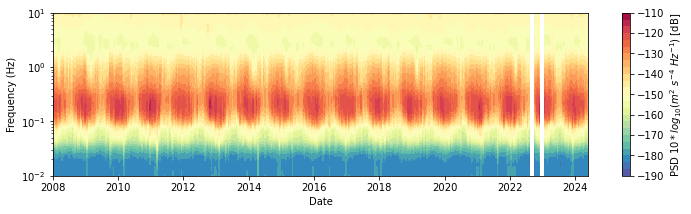

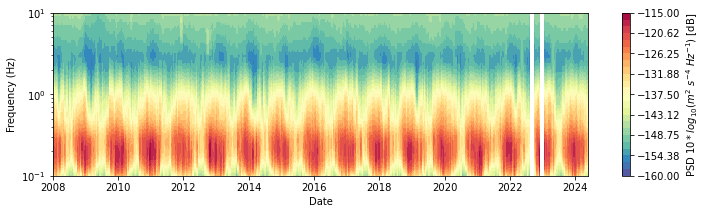

In [ ]:
# Plot spectrogram of seismic noise

fig = plt.figure(figsize=(12,3))
ax = plt.axes()
levels = np.linspace(-190,-110,25)
c = ax.contourf(ts,fs,PSDs,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='Spectral_r')
cb = plt.colorbar(c)
cb.set_label(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')
ax.set_ylim(1/100,10)

fig = plt.figure(figsize=(12,3))
ax = plt.axes()
levels = np.linspace(-160,-115,25)
c = ax.contourf(ts,fs,PSDs,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='Spectral_r')
cb = plt.colorbar(c)
cb.set_label(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')
ax.set_ylim(1/10,10)

Text(0, 0.5, 'PSD $10*log_{10}(m^2 s^{-4} Hz^{-1})$ [dB]')

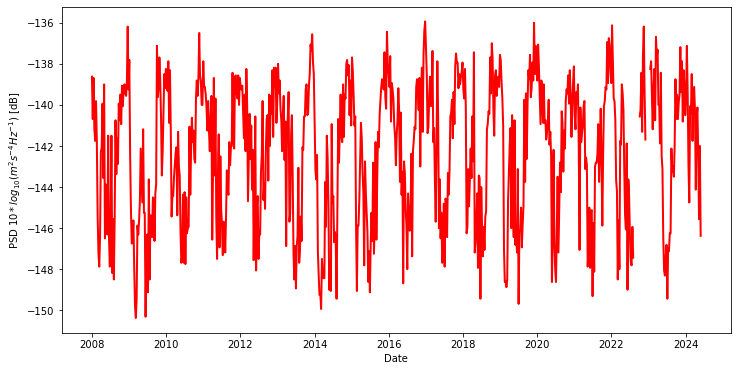

In [ ]:
import scipy

# Calculate power within frequency band

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 2 #1/0.65
# fmin = 0.2*2
# fmax = 0.4*2
# fmin = 1/10
# fmax = 1
# fmin = 1
# fmax = 2

PSD_band = PSDs[:,(freqs>=fmin) & (freqs<=fmax)].mean(axis=1)

fig = plt.figure(figsize=(12,6))
ax = plt.axes()
ax.plot(datevec, PSD_band, '-', c='r', lw=2)
ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='k')

ax.set_xlabel('Date')
ax.set_ylabel(r'PSD $10*log_{10}(m^2 s^{-4} Hz^{-1})$ [dB]')
